# 🖼️ Exercício: Quantização de Cores com KMeans

Neste exercício, você irá utilizar o algoritmo **KMeans** para realizar **quantização de cores** em uma imagem. Isso consiste em reduzir o número de cores utilizadas, aproximando cada pixel para o centro de um dos clusters. É uma técnica útil em compressão e estilização de imagens.

---

## ✅ Passo 1: Carregue a imagem

Use a biblioteca `PIL` para abrir a imagem e converter para o formato RGB.

    from PIL import Image
    import numpy as np

    image_path = "..."  # substitua pelo caminho da sua imagem
    img = Image.open(image_path).convert("RGB")
    img_np = np.array(img)
    original_shape = img_np.shape

---

## ✅ Passo 2: Transforme a imagem em uma matriz de pixels

A imagem precisa ser convertida para uma matriz onde cada linha representa um pixel (com 3 colunas: R, G, B).

    pixels = img_np.reshape(-1, 3)

---

## ✅ Passo 3: Aplique o KMeans

Use `KMeans` com `n_clusters = k` para agrupar as cores dominantes da imagem.

    from sklearn.cluster import KMeans

    k = 50  # número de cores desejado (varie esse valor depois!)
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(pixels)
    new_colors = kmeans.cluster_centers_.astype(np.uint8)
    quantized_pixels = new_colors[labels]

---

## ✅ Passo 4: Reconstrua a imagem quantizada

Agora, reconstrua a imagem com as novas cores agrupadas.

    quantized_img = quantized_pixels.reshape(original_shape)

---

## ✅ Passo 5: Visualize o resultado

Plote lado a lado a imagem original e a imagem quantizada usando `matplotlib`.

    import matplotlib.pyplot as plt

    fig, axs = plt.subplots(1, 2, figsize=(12, 6))

    axs[0].imshow(img_np)
    axs[0].set_title("Imagem Original")
    axs[0].axis("off")

    axs[1].imshow(quantized_img)
    axs[1].set_title(f"Imagem Quantizada (k = {k})")
    axs[1].axis("off")

    plt.tight_layout()
    plt.show()

---

## 🧪 Experimento

Teste diferentes valores de `k` e veja o efeito na imagem quantizada:

- Experimente: `k = 2`, `4`, `8`, `16`, `32`, `64`, `128`
- Quais valores geram imagens visualmente aceitáveis?
- Em que ponto a imagem começa a perder muitos detalhes?

---

## 🎯 Reflexão

- Como o número de cores influencia na qualidade visual da imagem?
- A quantização com KMeans pode ser usada como forma de compressão?
- Esse método funcionaria bem em outras imagens com diferentes estilos ou paletas de cores?

---


Original Shape: (408, 612, 3)
Pixels Shape: (249696, 3)


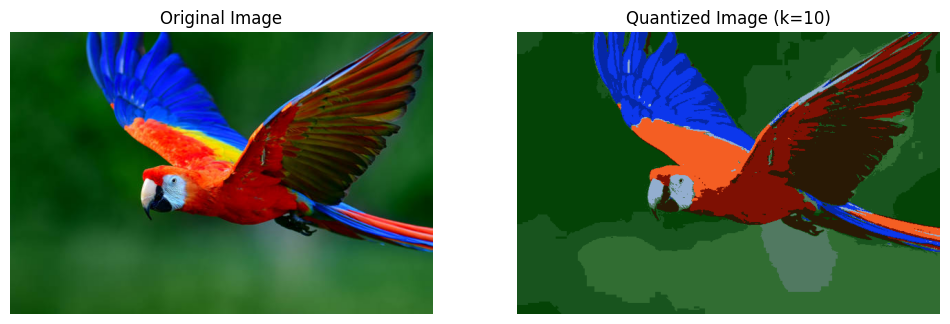

In [9]:
# By Vitor Mello
from PIL import Image
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1 Carregar a imagem
image_path = "arara.png"
img = Image.open(image_path).convert("RGB")
img_np = np.array(img)
original_shape = img_np.shape

print(f"Original Shape: {original_shape}")

# 2 Transformar a imagem em uma matriz de pixels
pixels = img_np.reshape(-1, 3)
print(f"Pixels Shape: {pixels.shape}")

# 3 KMeean
k = 10
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(pixels)
new_colors = kmeans.cluster_centers_.astype(np.uint8)
quantized_pixels = new_colors[labels]

# 4 Reconstruir imagem
quantized_img = quantized_pixels.reshape(original_shape)

# 5 Mostrar resultado final
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].imshow(img_np)
axs[0].set_title("Original Image")
axs[0].axis("off")
axs[1].imshow(quantized_img)
axs[1].set_title(f"Quantized Image (k={k})")
axs[1].axis("off")

plt.show()

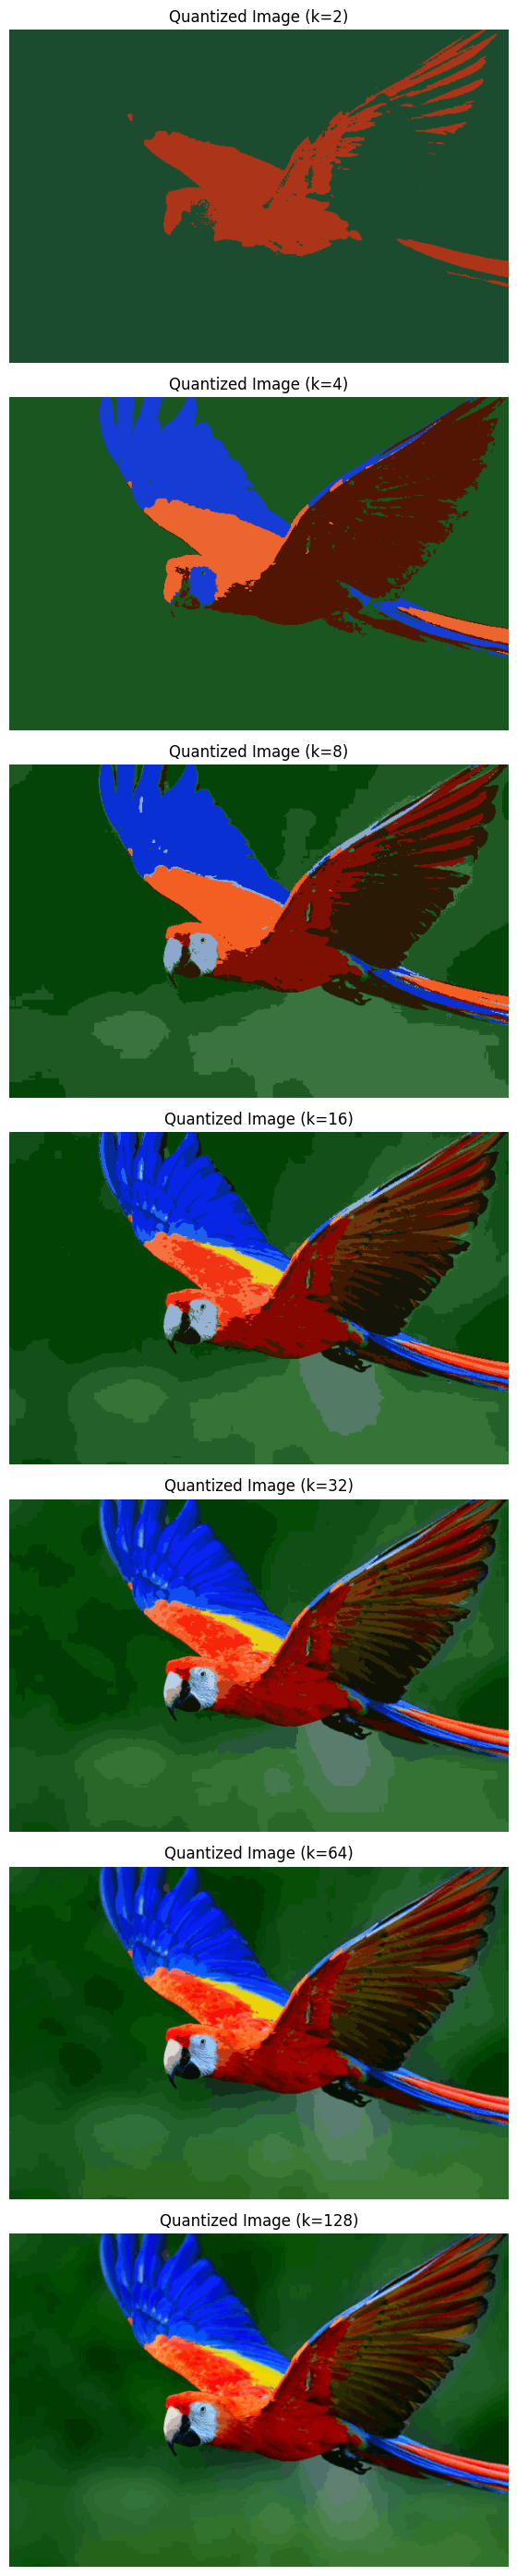

In [12]:
# Testes

def image_kmeans(pixels, k):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(pixels)
    new_colors = kmeans.cluster_centers_.astype(np.uint8)
    quantized_pixels = new_colors[labels]

    quantized_img = quantized_pixels.reshape(original_shape)

    return quantized_img


image_path = "arara.png"
img = Image.open(image_path).convert("RGB")
img_np = np.array(img)
original_shape = img_np.shape
pixels = img_np.reshape(-1, 3)

k_list = [2**i for i in range(1, 8)]
fig, axs = plt.subplots(len(k_list), 1, figsize=(6, 4*len(k_list)))

for ax, k in zip(axs, k_list):
    img_result = image_kmeans(pixels=pixels, k=k)
    ax.imshow(img_result)
    ax.set_title(f"Quantized Image (k={k})")
    ax.axis("off")

fig.tight_layout()

1. Como o número de cores influencia na qualidade visual da imagem depois de aplicar kmeans? <br>
Nesse exercício o número de cores é igual ao parametro k fo kmeans, logo quanto maior melhor

2. A quantização com kmeans pode ser usada como forma de compressão? <br>
A imagem tem menos informação, para funcionar como compressão temos que utilizar um metodo de armazenamento inteligente que consegue fazer uso dessa redução de informação

From wikipedia:
> The selected colors are specified in the color palette in the header of the compressed image. Each pixel just references the index of a color in the color palette. This method can be combined with dithering to avoid posterization.

3. Esse método funciona bem em outras imagens com diferentes estilos ou paletas de cores? <br>
O kmeans se beneficia de diferente numeros de cores e mudanças brucas de cores. Se a imagem fugir desse padrão o metodo pode precisar de um número elevado de cores para gerar um bom resultado
